<a href="https://colab.research.google.com/github/Gustavo-Pinho/An-lise-Financeira-do-Grupo-SOMMA/blob/main/Analise_Financeira_SOMMA_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎵 Análise Financeira — Agência de Marketing de Influência Musical
## Desafio Técnico: Analista de Dados Financeiros Júnior
---
**Período analisado:** Q1 2026 (Janeiro – Março)  
**Fonte de dados:** Desafio Técnico Analista Financeiro - Base de Dados.xlsx  
**Objetivo:** Construir visão financeira e operacional completa da agência, respondendo às perguntas do desafio com análises visuais e recomendações práticas.

---

In [1]:
# ─── Importações e Configurações ────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# Estilo visual personalizado
plt.rcParams.update({
    'figure.facecolor': '#1A1A2E',
    'axes.facecolor': '#16213E',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#CCCCCC',
    'axes.titlecolor': '#FFFFFF',
    'xtick.color': '#AAAAAA',
    'ytick.color': '#AAAAAA',
    'text.color': '#FFFFFF',
    'grid.color': '#333355',
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
})

# Paleta
COLORS = {
    'primary':   '#00B4D8',
    'accent':    '#E94560',
    'warning':   '#F4A261',
    'success':   '#2DC653',
    'info':      '#3498DB',
    'purple':    '#9B59B6',
    'bg_dark':   '#1A1A2E',
    'bg_card':   '#16213E',
    'muted':     '#888888',
}
MES_COLORS = ['#00B4D8', '#F4A261', '#E94560']

print("✅ Configurações carregadas com sucesso.")

✅ Configurações carregadas com sucesso.


---
## 📥 1. Carregamento e Limpeza dos Dados

In [2]:
# ─── Carregamento das Abas ───────────────────────────────────────────────────
FILE = '/content/Desafio Técnico Analista Financeiro - Base de Dados (1) (1).xlsx'

campanhas = pd.read_excel(FILE, sheet_name='Campanhas 2026')
custos    = pd.read_excel(FILE, sheet_name='Custos')
resumo    = pd.read_excel(FILE, sheet_name='Resumo Mensal')

print(f"📋 Campanhas: {campanhas.shape}")
print(f"💰 Custos:    {custos.shape}")
print(f"📅 Resumo:    {resumo.shape}")

📋 Campanhas: (71, 13)
💰 Custos:    (71, 6)
📅 Resumo:    (17, 7)


In [3]:
# ─── Limpeza e Enriquecimento ────────────────────────────────────────────────
campanhas['Mês Num']  = campanhas['Data Início'].dt.month
campanhas['Mês Nome'] = campanhas['Mês Num'].map({1:'Janeiro', 2:'Fevereiro', 3:'Março'})

df = campanhas.merge(
    custos[['Código','Verba da Campanha (R$)','Custo Operacional (R$)',
            '% Verba Utilizada','Qtd Posts']],
    on='Código', how='left'
)

# CPM: Valor Campanha / Views * 1000
df['Views Entregues'] = pd.to_numeric(df['Views Entregues'], errors='coerce')
df['CPM'] = np.where(
    (df['Views Entregues'] > 0) & (df['Campanha Finalizada'] == 'Sim'),
    df['Valor Campanha (R$)'] / df['Views Entregues'] * 1000,
    np.nan
)

# Classificação de Margem
df['Status Margem'] = df['% Verba Utilizada'].apply(
    lambda x: 'Dentro' if pd.notna(x) and x <= 0.5
              else ('Estourou' if pd.notna(x) else 'Sem Dado')
)

print("✅ Dataset enriquecido. Shape final:", df.shape)
print()
print("📊 Campos com valores nulos:")
print(df.isnull().sum()[df.isnull().sum() > 0])

✅ Dataset enriquecido. Shape final: (71, 21)

📊 Campos com valores nulos:
Código                     1
Música                     1
Artista                    1
Gênero                     1
Contato                    1
Empresa/Label              1
Data Início                1
Data Fim                   1
Responsável                1
Pagamento Realizado        1
Campanha Finalizada        1
Views Entregues            1
Mês Num                    1
Mês Nome                   1
Verba da Campanha (R$)     1
Custo Operacional (R$)     1
% Verba Utilizada          1
Qtd Posts                  1
CPM                       20
dtype: int64


In [4]:
# ─── Visão Geral dos Dados ───────────────────────────────────────────────────
print("=" * 60)
print("RESUMO DO DATASET")
print("=" * 60)
print(f"  Total de campanhas:      {len(df)}")
print(f"  Campanhas finalizadas:   {(df['Campanha Finalizada']=='Sim').sum()}")
print(f"  Pagamentos realizados:   {(df['Pagamento Realizado']=='Sim').sum()}")
print(f"  Artistas únicos:         {df['Artista'].nunique()}")
print(f"  Labels/Empresas:         {df['Empresa/Label'].nunique()}")
print(f"  Gêneros musicais:        {df['Gênero'].nunique()}")
print(f"  Responsáveis:            {df['Responsável'].nunique()}")
print(f"  Período:                 {df['Data Início'].min().date()} a {df['Data Fim'].max().date()}")
print("=" * 60)
df.head(5)

RESUMO DO DATASET
  Total de campanhas:      71
  Campanhas finalizadas:   51
  Pagamentos realizados:   51
  Artistas únicos:         29
  Labels/Empresas:         7
  Gêneros musicais:        11
  Responsáveis:            4
  Período:                 2026-01-07 a 2026-05-04


,Código,Música,Artista,Gênero,Contato,Empresa/Label,Data Início,Data Fim,Responsável,Valor Campanha (R$),...,Campanha Finalizada,Views Entregues,Mês Num,Mês Nome,Verba da Campanha (R$),Custo Operacional (R$),% Verba Utilizada,Qtd Posts,CPM,Status Margem
0,#CMP1001,Manda o Pix,Kauan Silva,Pagode,Felipe Gabriel,Estrela Distribuição,2026-01-07,2026-01-14,Analista 2,20000,...,Sim,22228000.0,1.0,Janeiro,20000.0,11710.0,0.585500,292.0,0.899766,Estourou
1,#CMP1002,Pra Sempre,Kauan Silva,Trap,Rodrigo Almeida,Onda Records,2026-01-07,2026-01-21,Analista 2,2000,...,Sim,3862000.0,1.0,Janeiro,2000.0,1390.0,0.695000,20.0,0.517866,Estourou
2,#CMP1003,Funk Raiz,Gabi Noronha,Sertanejo,Beatriz Nunes,Pulse Music Group,2026-01-08,2026-01-08,Coordenador,5000,...,Sim,6437000.0,1.0,Janeiro,5000.0,3300.0,0.660000,44.0,0.776759,Estourou
3,#CMP1004,Conexão,Gabi Noronha,R&B,Felipe Gabriel,Tropicália Music,2026-01-09,2026-01-12,Analista 3,35000,...,Sim,50297000.0,1.0,Janeiro,35000.0,22160.0,0.633143,611.0,0.695867,Estourou
4,#CMP1005,Tropa do Barulho,Duo Marejada,Funk,Felipe Gabriel,Pulse Music Group,2026-01-11,2026-01-18,Analista 2,23000,...,Sim,61563000.0,1.0,Janeiro,23000.0,14300.0,0.621739,411.0,0.373601,Estourou


---
## 📊 Parte 1 — Visão Financeira

### (a) Faturamento mês a mês no Q1 e comparação com a meta anual

In [5]:
# ─── Faturamento Mensal ──────────────────────────────────────────────────────
META_ANUAL  = 6_000_000
META_MENSAL = META_ANUAL / 12

fat_mes = df.groupby('Mês Nome').agg(
    Faturamento=('Valor Campanha (R$)', 'sum'),
    Campanhas=('Código', 'count')
).reindex(['Janeiro','Fevereiro','Março'])

fat_mes['Meta Mensal']  = META_MENSAL
fat_mes['Diferença']    = fat_mes['Faturamento'] - META_MENSAL
fat_mes['% Meta']       = fat_mes['Faturamento'] / META_MENSAL
fat_mes['Ticket Médio'] = fat_mes['Faturamento'] / fat_mes['Campanhas']

print("FATURAMENTO POR MÊS — Q1 2026")
print("-" * 55)
for mes, row in fat_mes.iterrows():
    status = "✅" if row['Diferença'] >= 0 else "⚠️"
    print(f"  {status} {mes:<12} R$ {row['Faturamento']:>10,.0f}  |  {row['% Meta']*100:.1f}% da meta mensal")
print("-" * 55)
total_q1 = fat_mes['Faturamento'].sum()
print(f"  TOTAL Q1:    R$ {total_q1:>10,.0f}  |  {total_q1/META_ANUAL*100:.1f}% da meta ANUAL")
print()
ritmo = total_q1 / 3
proj  = ritmo * 12
print(f"  Ritmo mensal atual: R$ {ritmo:,.0f}")
print(f"  Projeção anual:     R$ {proj:,.0f}")
print(f"  Meta anual:         R$ {META_ANUAL:,.0f}")
print(f"  GAP para a meta:    R$ {META_ANUAL - proj:,.0f} ({'⚠️ abaixo do ritmo' if proj < META_ANUAL else '✅ no ritmo'})")

FATURAMENTO POR MÊS — Q1 2026
-------------------------------------------------------
  ✅ Janeiro      R$    567,000  |  113.4% da meta mensal
  ✅ Fevereiro    R$    518,000  |  103.6% da meta mensal
  ⚠️ Março        R$    351,500  |  70.3% da meta mensal
-------------------------------------------------------
  TOTAL Q1:    R$  1,436,500  |  23.9% da meta ANUAL

  Ritmo mensal atual: R$ 478,833
  Projeção anual:     R$ 5,746,000
  Meta anual:         R$ 6,000,000
  GAP para a meta:    R$ 254,000 (⚠️ abaixo do ritmo)


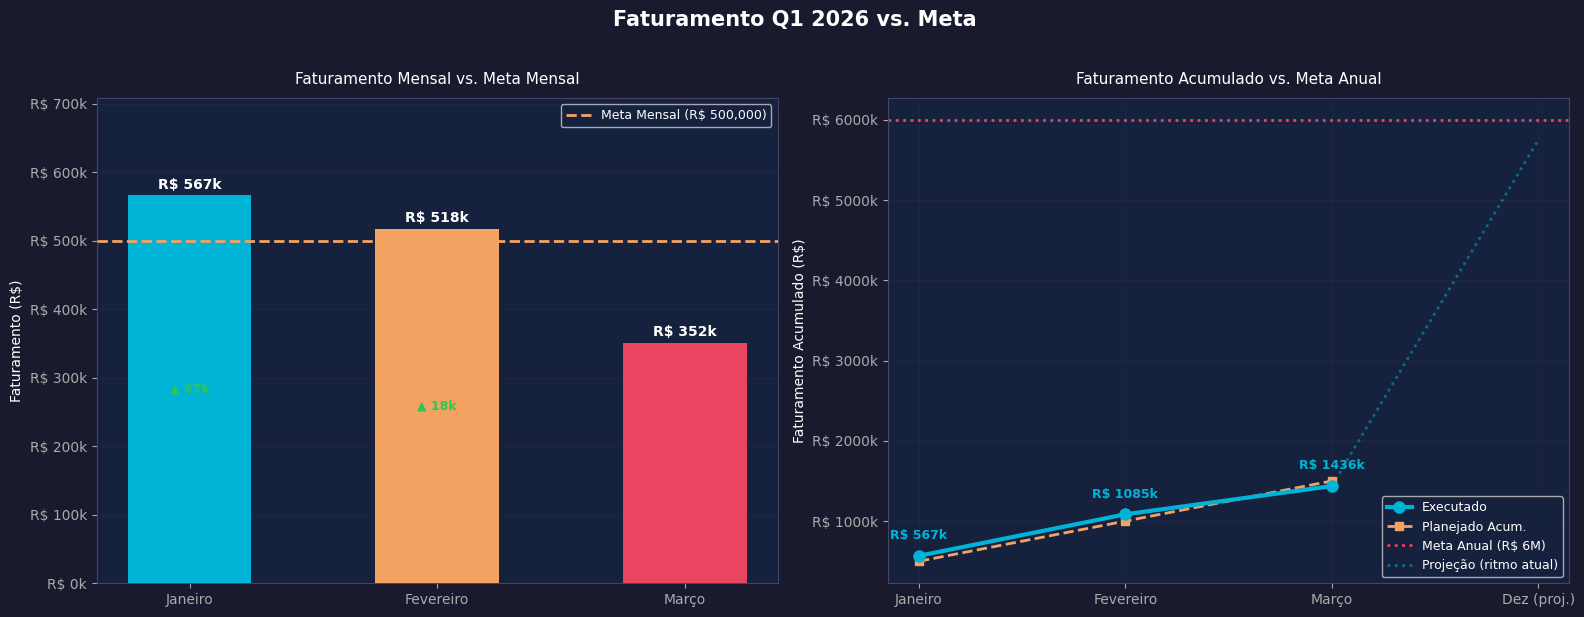

📈 Gráfico salvo.


In [6]:
# ─── Gráfico: Faturamento Mensal vs Meta ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(COLORS['bg_dark'])
fig.suptitle('Faturamento Q1 2026 vs. Meta', fontsize=15, fontweight='bold', color='white', y=1.02)

# ── Barras: mensal
ax1 = axes[0]
ax1.set_facecolor(COLORS['bg_card'])
meses = fat_mes.index.tolist()
vals  = fat_mes['Faturamento'].values
bars  = ax1.bar(meses, vals, color=MES_COLORS, width=0.5, zorder=3)
ax1.axhline(META_MENSAL, color=COLORS['warning'], lw=2, ls='--', label=f'Meta Mensal (R$ {META_MENSAL:,.0f})', zorder=4)
for bar, val, dif in zip(bars, vals, fat_mes['Diferença'].values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'R$ {val/1000:.0f}k', ha='center', va='bottom', fontweight='bold', fontsize=10)
    icon = '▲' if dif >= 0 else '▼'
    color = COLORS['success'] if dif >= 0 else COLORS['accent']
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
             f'{icon} {abs(dif)/1000:.0f}k', ha='center', va='center',
             color=color, fontsize=9, fontweight='bold')
ax1.set_title('Faturamento Mensal vs. Meta Mensal', fontsize=11, color='white', pad=10)
ax1.set_ylabel('Faturamento (R$)', color='white')
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}k'))
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, max(vals) * 1.25)

# ── Linha: acumulado vs meta
ax2 = axes[1]
ax2.set_facecolor(COLORS['bg_card'])
exec_acum  = [567000, 1085000, 1436500]
plan_acum  = [500000, 1000000, 1500000]
meta_full  = list(range(500000, 6_500_000, 500000))
meses_full = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

ax2.plot(meses[:3], exec_acum, color=COLORS['primary'], lw=3, marker='o', ms=8,
         label='Executado', zorder=5)
ax2.plot(meses[:3], plan_acum, color=COLORS['warning'], lw=2, ls='--', marker='s', ms=6,
         label='Planejado Acum.', zorder=4)
ax2.axhline(META_ANUAL, color=COLORS['accent'], lw=2, ls=':', label='Meta Anual (R$ 6M)')

# Projeção
ax2.plot(['Março', 'Dez (proj.)'], [1_436_500, 1_436_500 + 9*ritmo],
         color=COLORS['primary'], lw=2, ls=':', alpha=0.5, label='Projeção (ritmo atual)')

for x, y, v in zip(meses[:3], exec_acum, exec_acum):
    ax2.annotate(f'R$ {v/1000:.0f}k', (x, y), textcoords="offset points",
                 xytext=(0, 12), ha='center', fontsize=9, color=COLORS['primary'], fontweight='bold')
ax2.set_title('Faturamento Acumulado vs. Meta Anual', fontsize=11, color='white', pad=10)
ax2.set_ylabel('Faturamento Acumulado (R$)', color='white')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}k'))
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_faturamento_mensal.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg_dark'])
plt.show()
print("📈 Gráfico salvo.")

### (b) O que é necessário para bater a meta até dezembro?

In [7]:
# ─── Análise de Ritmo e Cenários ────────────────────────────────────────────
total_q1 = 1_436_500
meses_restantes = 9
gap = META_ANUAL - total_q1
ticket_medio = df['Valor Campanha (R$)'].mean()
camp_por_mes_atual = len(df) // 3

necessario_mes = gap / meses_restantes
camp_necessarias = np.ceil(necessario_mes / ticket_medio)

print("=" * 62)
print("ANÁLISE: PARA BATER A META DE R$ 6.000.000")
print("=" * 62)
print(f"  ✅ Já executado (Q1):            R$ {total_q1:>12,.0f}")
print(f"  🎯 Meta anual:                   R$ {META_ANUAL:>12,.0f}")
print(f"  📉 Falta executar (Q2-Q4):       R$ {gap:>12,.0f}")
print(f"  📅 Meses restantes:              {meses_restantes} meses")
print("-" * 62)
print(f"  💡 Receita necessária/mês:       R$ {necessario_mes:>12,.0f}")
print(f"  📊 Ritmo atual (campanha/mês):   {camp_por_mes_atual} campanhas")
print(f"  📊 Ticket médio atual:           R$ {ticket_medio:>12,.0f}")
print(f"  🚀 Campanhas necessárias/mês:    ~{camp_necessarias:.0f} campanhas")
print(f"  ⬆️  Aumento necessário:          +{camp_necessarias-camp_por_mes_atual:.0f} campanhas/mês (+{(camp_necessarias/camp_por_mes_atual-1)*100:.0f}%)")
print("=" * 62)
print()
print("CENÁRIOS ALTERNATIVOS:")
print("-" * 62)
for aumento_ticket in [0.10, 0.20, 0.30]:
    novo_ticket = ticket_medio * (1 + aumento_ticket)
    camp_necessarias_cen = np.ceil(necessario_mes / novo_ticket)
    print(f"  Ticket +{aumento_ticket*100:.0f}% (R$ {novo_ticket:,.0f}): "
          f"~{camp_necessarias_cen:.0f} campanhas/mês")

ANÁLISE: PARA BATER A META DE R$ 6.000.000
  ✅ Já executado (Q1):            R$    1,436,500
  🎯 Meta anual:                   R$    6,000,000
  📉 Falta executar (Q2-Q4):       R$    4,563,500
  📅 Meses restantes:              9 meses
--------------------------------------------------------------
  💡 Receita necessária/mês:       R$      507,056
  📊 Ritmo atual (campanha/mês):   23 campanhas
  📊 Ticket médio atual:           R$       40,465
  🚀 Campanhas necessárias/mês:    ~13 campanhas
  ⬆️  Aumento necessário:          +-10 campanhas/mês (+-43%)

CENÁRIOS ALTERNATIVOS:
--------------------------------------------------------------
  Ticket +10% (R$ 44,511): ~12 campanhas/mês
  Ticket +20% (R$ 48,558): ~11 campanhas/mês
  Ticket +30% (R$ 52,604): ~10 campanhas/mês


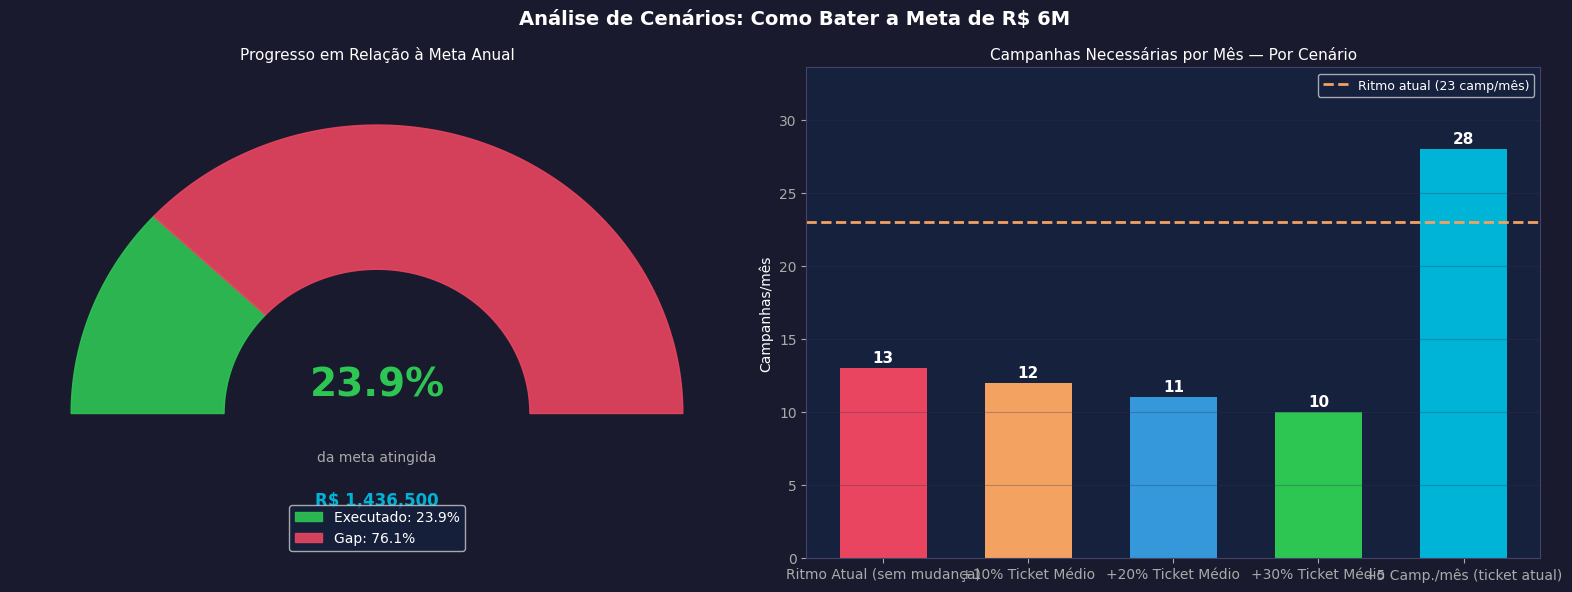

In [9]:
# ─── Gráfico: Cenários para bater a meta ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(COLORS['bg_dark'])
fig.suptitle('Análise de Cenários: Como Bater a Meta de R$ 6M',
             fontsize=14, fontweight='bold', color='white')

# ── Gauge do progresso
ax1 = axes[0]
ax1.set_facecolor(COLORS['bg_card'])
pct_atingida = total_q1 / META_ANUAL
theta_exec  = pct_atingida * np.pi
theta_gap   = (1 - pct_atingida) * np.pi

angles_exec = np.linspace(np.pi, np.pi - theta_exec, 100)
angles_gap  = np.linspace(np.pi - theta_exec, 0, 100)
r_in, r_out = 0.5, 1.0

def arc(ax, angles, r_in, r_out, color, label=''):
    xs = np.concatenate([r_out*np.cos(angles), r_in*np.cos(angles[::-1])])
    ys = np.concatenate([r_out*np.sin(angles), r_in*np.sin(angles[::-1])])
    ax.fill(xs, ys, color=color, alpha=0.9, label=label)

arc(ax1, angles_exec, r_in, r_out, COLORS['success'], f'Executado: {pct_atingida*100:.1f}%')
arc(ax1, angles_gap,  r_in, r_out, COLORS['accent'],  f'Gap: {(1-pct_atingida)*100:.1f}%')
ax1.text(0, 0.1, f'{pct_atingida*100:.1f}%', ha='center', va='center',
         fontsize=28, fontweight='bold', color=COLORS['success'])
ax1.text(0, -0.15, 'da meta atingida', ha='center', va='center', fontsize=10, color='#AAAAAA')
ax1.text(0, -0.3, f'R$ {total_q1:,.0f}', ha='center', va='center',
         fontsize=12, fontweight='bold', color=COLORS['primary'])
ax1.set_xlim(-1.2, 1.2); ax1.set_ylim(-0.5, 1.2)
ax1.axis('off')
ax1.legend(loc='lower center', fontsize=10)
ax1.set_title('Progresso em Relação à Meta Anual', color='white', fontsize=11)

# ── Barras de cenários
ax2 = axes[1]
ax2.set_facecolor(COLORS['bg_card'])
cenario_labels = ['Ritmo Atual (sem mudança)', '+10% Ticket Médio', '+20% Ticket Médio', '+30% Ticket Médio', '+5 Camp./mês (ticket atual)']
camp_cen = [camp_necessarias,
            np.ceil(necessario_mes/(ticket_medio*1.1)),
            np.ceil(necessario_mes/(ticket_medio*1.2)),
            np.ceil(necessario_mes/(ticket_medio*1.3)),
            camp_por_mes_atual + 5]
rec_cen = [c * ticket_medio for c in camp_cen[:4]] + [(camp_por_mes_atual+5)*ticket_medio]
colors_cen = [COLORS['accent'], COLORS['warning'], COLORS['info'], COLORS['success'], COLORS['primary']]

bars2 = ax2.bar(cenario_labels, camp_cen, color=colors_cen, width=0.6)
ax2.axhline(camp_por_mes_atual, color=COLORS['warning'], lw=2, ls='--',
            label=f'Ritmo atual ({camp_por_mes_atual} camp/mês)')
for bar, c in zip(bars2, camp_cen):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{c:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_title('Campanhas Necessárias por Mês — Por Cenário', color='white', fontsize=11)
ax2.set_ylabel('Campanhas/mês', color='white')
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, max(camp_cen) * 1.2)

plt.tight_layout()
plt.savefig('grafico_cenarios_meta.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg_dark'])
plt.show()

### (c) Ticket médio das campanhas — por mês, artista e empresa

In [10]:
# ─── Ticket Médio ────────────────────────────────────────────────────────────
print(f"Ticket Médio Geral: R$ {df['Valor Campanha (R$)'].mean():,.0f}")
print()
print("Por Mês:")
print(df.groupby('Mês Nome')['Valor Campanha (R$)'].mean().reindex(['Janeiro','Fevereiro','Março'])
      .map(lambda x: f'R$ {x:,.0f}').to_string())
print()
print("Top 10 Artistas por Ticket Médio:")
print(df.groupby('Artista')['Valor Campanha (R$)'].mean().sort_values(ascending=False)
      .head(10).map(lambda x: f'R$ {x:,.0f}').to_string())
print()
print("Por Label/Empresa:")
print(df.groupby('Empresa/Label')['Valor Campanha (R$)'].mean().sort_values(ascending=False)
      .map(lambda x: f'R$ {x:,.0f}').to_string())

Ticket Médio Geral: R$ 40,465

Por Mês:
Mês Nome
Janeiro      R$ 28,350
Fevereiro    R$ 20,720
Março        R$ 14,060

Top 10 Artistas por Ticket Médio:
Artista
Rick Montana         R$ 37,200
Isa Monteiro         R$ 36,000
Tom Barreto          R$ 34,000
Gabi Noronha         R$ 33,333
Bia Santos           R$ 30,000
Lucas Prado          R$ 28,667
Beto Correia         R$ 26,600
Matheus e Gabriel    R$ 26,500
Grupo Maré Alta      R$ 22,667
Grupo Ventania       R$ 22,250

Por Label/Empresa:
Empresa/Label
Pulse Music Group       R$ 28,000
Estrela Distribuição    R$ 23,000
Onda Records            R$ 21,650
Beat Factory            R$ 21,111
Tropicália Music        R$ 20,500
Nova Sound              R$ 14,800
Ritmo Digital           R$ 13,571


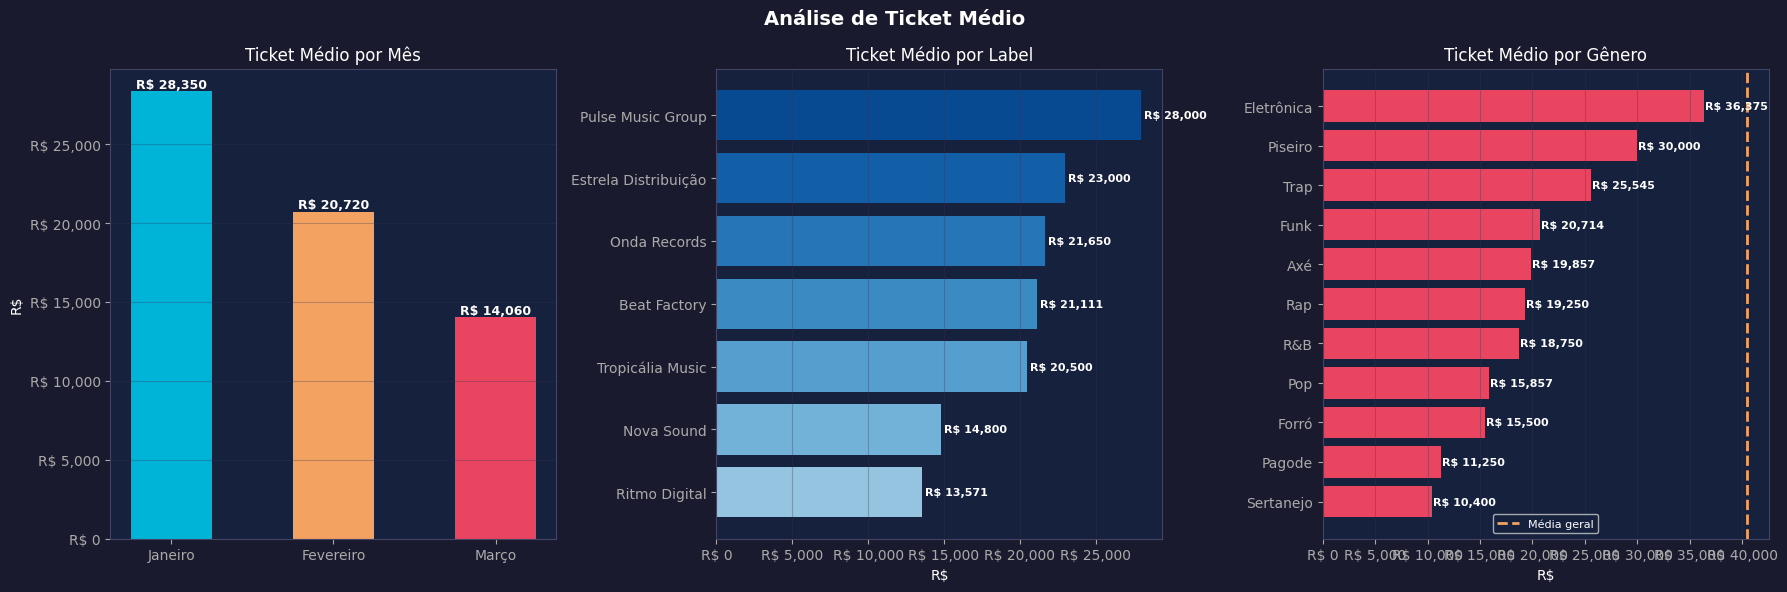

In [11]:
# ─── Gráfico: Ticket Médio ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(COLORS['bg_dark'])
fig.suptitle('Análise de Ticket Médio', fontsize=14, fontweight='bold', color='white')

# Por Mês
ax1 = axes[0]
ax1.set_facecolor(COLORS['bg_card'])
ticket_mes = df.groupby('Mês Nome')['Valor Campanha (R$)'].mean().reindex(['Janeiro','Fevereiro','Março'])
bars = ax1.bar(ticket_mes.index, ticket_mes.values, color=MES_COLORS, width=0.5)
for bar, val in zip(bars, ticket_mes.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'R$ {val:,.0f}', ha='center', fontsize=9, fontweight='bold')
ax1.set_title('Ticket Médio por Mês', color='white')
ax1.set_ylabel('R$', color='white')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R$ {x:,.0f}'))
ax1.grid(axis='y', alpha=0.3)

# Por Label
ax2 = axes[1]
ax2.set_facecolor(COLORS['bg_card'])
ticket_label = df.groupby('Empresa/Label')['Valor Campanha (R$)'].mean().sort_values()
colors_l = plt.cm.Blues(np.linspace(0.4, 0.9, len(ticket_label)))
bars2 = ax2.barh(ticket_label.index, ticket_label.values, color=colors_l)
for bar, val in zip(bars2, ticket_label.values):
    ax2.text(val+200, bar.get_y()+bar.get_height()/2,
             f'R$ {val:,.0f}', va='center', fontsize=8, fontweight='bold')
ax2.set_title('Ticket Médio por Label', color='white')
ax2.set_xlabel('R$', color='white')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R$ {x:,.0f}'))
ax2.grid(axis='x', alpha=0.3)

# Por Gênero
ax3 = axes[2]
ax3.set_facecolor(COLORS['bg_card'])
ticket_gen = df.groupby('Gênero')['Valor Campanha (R$)'].mean().sort_values()
colors_g = [COLORS['success'] if v >= df['Valor Campanha (R$)'].mean() else COLORS['accent'] for v in ticket_gen.values]
bars3 = ax3.barh(ticket_gen.index, ticket_gen.values, color=colors_g)
ax3.axvline(df['Valor Campanha (R$)'].mean(), color=COLORS['warning'], lw=2, ls='--', label='Média geral')
for bar, val in zip(bars3, ticket_gen.values):
    ax3.text(val+100, bar.get_y()+bar.get_height()/2,
             f'R$ {val:,.0f}', va='center', fontsize=8, fontweight='bold')
ax3.set_title('Ticket Médio por Gênero', color='white')
ax3.set_xlabel('R$', color='white')
ax3.legend(fontsize=8)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R$ {x:,.0f}'))
ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_ticket_medio.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg_dark'])
plt.show()

### (d) Análise de Margem Operacional — Regra dos 50%

In [12]:
# ─── Análise de Margem ───────────────────────────────────────────────────────
df_margem = df[df['Status Margem'] != 'Sem Dado'].copy()
dentro     = (df_margem['Status Margem'] == 'Dentro').sum()
estourou   = (df_margem['Status Margem'] == 'Estourou').sum()
total_m    = len(df_margem)
margem_avg = df_margem['% Verba Utilizada'].mean()
margem_med = df_margem['% Verba Utilizada'].median()

print("=" * 58)
print("ANÁLISE DE MARGEM OPERACIONAL — REGRA DOS 50%")
print("=" * 58)
print(f"  Campanhas com custo informado:  {total_m}")
print(f"  ✅ Dentro da margem (≤ 50%):    {dentro}  ({dentro/total_m*100:.0f}%)")
print(f"  🔴 Estouraram a margem (> 50%): {estourou}  ({estourou/total_m*100:.0f}%)")
print("-" * 58)
print(f"  Margem média:                   {margem_avg*100:.1f}%")
print(f"  Margem mediana:                 {margem_med*100:.1f}%")
print(f"  Limite da regra:                50.0%")
print(f"  Excedente médio:                +{(margem_avg-0.5)*100:.1f} p.p. acima do limite")
print("=" * 58)
print()
print("Top 5 campanhas com MAIOR custo relativo:")
print(df_margem.sort_values('% Verba Utilizada', ascending=False)
      [['Código','Artista','Gênero','% Verba Utilizada','Custo Operacional (R$)']]
      .head(5).assign(**{'% Verba Utilizada': lambda x: x['% Verba Utilizada'].map(lambda v: f'{v*100:.1f}%')})
      .to_string(index=False))

ANÁLISE DE MARGEM OPERACIONAL — REGRA DOS 50%
  Campanhas com custo informado:  70
  ✅ Dentro da margem (≤ 50%):    17  (24%)
  🔴 Estouraram a margem (> 50%): 53  (76%)
----------------------------------------------------------
  Margem média:                   57.0%
  Margem mediana:                 57.4%
  Limite da regra:                50.0%
  Excedente médio:                +7.0 p.p. acima do limite

Top 5 campanhas com MAIOR custo relativo:
  Código        Artista     Gênero % Verba Utilizada  Custo Operacional (R$)
#CMP1020   Gabi Noronha Eletrônica             73.9%                 44310.0
#CMP1051  Rodrigo Neves        Axé             70.7%                 12730.0
#CMP1011 Fernanda Costa       Trap             70.1%                 24540.0
#CMP1002    Kauan Silva       Trap             69.5%                  1390.0
#CMP1029 Grupo Ventania        R&B             69.0%                 20700.0


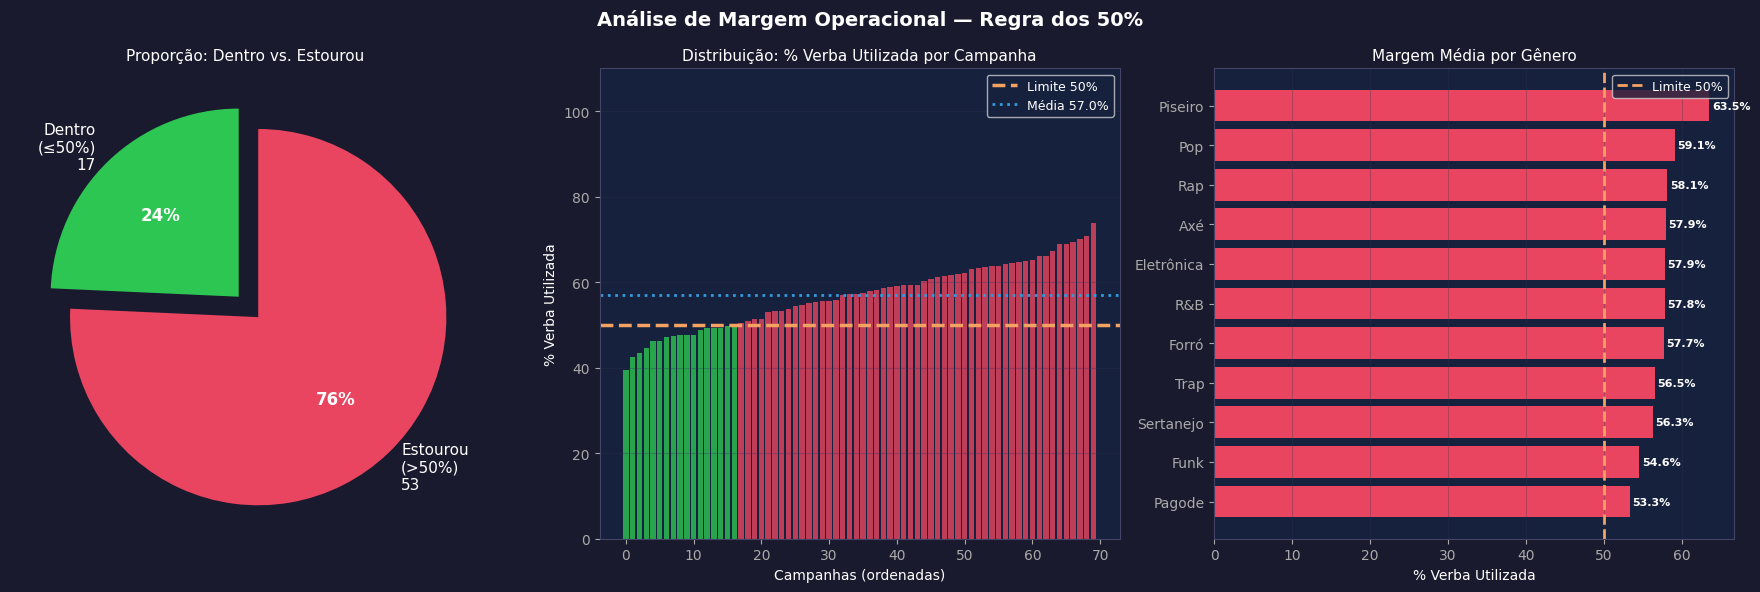

In [13]:
# ─── Gráfico: Análise de Margem ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(COLORS['bg_dark'])
fig.suptitle('Análise de Margem Operacional — Regra dos 50%', fontsize=14, fontweight='bold', color='white')

# Pie Chart
ax1 = axes[0]
ax1.set_facecolor(COLORS['bg_card'])
sizes  = [dentro, estourou]
labels = [f'Dentro\n(≤50%)\n{dentro}', f'Estourou\n(>50%)\n{estourou}']
explode = (0.05, 0.1)
wedges, texts, autotexts = ax1.pie(sizes, labels=labels, autopct='%1.0f%%',
    colors=[COLORS['success'], COLORS['accent']], explode=explode,
    startangle=90, textprops={'color':'white', 'fontsize':11})
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold')
ax1.set_title('Proporção: Dentro vs. Estourou', color='white', fontsize=11)

# Histograma distribuição
ax2 = axes[1]
ax2.set_facecolor(COLORS['bg_card'])
colors_hist = [COLORS['success'] if v <= 0.5 else COLORS['accent']
               for v in df_margem['% Verba Utilizada']]
ax2.bar(range(len(df_margem)),
        df_margem.sort_values('% Verba Utilizada')['% Verba Utilizada'].values * 100,
        color=[COLORS['success'] if v <= 50 else COLORS['accent']
               for v in df_margem.sort_values('% Verba Utilizada')['% Verba Utilizada'].values * 100],
        alpha=0.8)
ax2.axhline(50, color=COLORS['warning'], lw=2.5, ls='--', label='Limite 50%')
ax2.axhline(margem_avg*100, color=COLORS['info'], lw=2, ls=':', label=f'Média {margem_avg*100:.1f}%')
ax2.set_title('Distribuição: % Verba Utilizada por Campanha', color='white', fontsize=11)
ax2.set_xlabel('Campanhas (ordenadas)', color='white')
ax2.set_ylabel('% Verba Utilizada', color='white')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 110)

# Margem por Gênero
ax3 = axes[2]
ax3.set_facecolor(COLORS['bg_card'])
margem_genero = df_margem.groupby('Gênero')['% Verba Utilizada'].mean().sort_values() * 100
bar_colors = [COLORS['success'] if v <= 50 else COLORS['accent'] for v in margem_genero.values]
bars = ax3.barh(margem_genero.index, margem_genero.values, color=bar_colors)
ax3.axvline(50, color=COLORS['warning'], lw=2, ls='--', label='Limite 50%')
for bar, val in zip(bars, margem_genero.values):
    ax3.text(val+0.3, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')
ax3.set_title('Margem Média por Gênero', color='white', fontsize=11)
ax3.set_xlabel('% Verba Utilizada', color='white')
ax3.legend(fontsize=9)
ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_margem.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg_dark'])
plt.show()

### (e) Concentração de faturamento por label

In [14]:
# ─── Concentração por Label ──────────────────────────────────────────────────
fat_label = df.groupby('Empresa/Label').agg(
    Faturamento=('Valor Campanha (R$)', 'sum'),
    Campanhas=('Código', 'count')
).sort_values('Faturamento', ascending=False)

fat_label['% Faturamento'] = fat_label['Faturamento'] / fat_label['Faturamento'].sum() * 100
fat_label['Acumulado %']   = fat_label['% Faturamento'].cumsum()

exec_q1_total = fat_label['Faturamento'].sum()

print("CONCENTRAÇÃO DE FATURAMENTO POR LABEL")
print("-" * 60)
print(fat_label[['Faturamento','Campanhas','% Faturamento','Acumulado %']]
      .assign(Faturamento=fat_label['Faturamento'].map(lambda x: f'R$ {x:,.0f}'))
      .assign(**{'% Faturamento': fat_label['% Faturamento'].map(lambda x: f'{x:.1f}%')})
      .assign(**{'Acumulado %': fat_label['Acumulado %'].map(lambda x: f'{x:.1f}%')})
      .to_string())
print()
top3_pct = fat_label['% Faturamento'].head(3).sum()
top1_pct = fat_label['% Faturamento'].head(1).values[0]
print(f"⚠️  Top 1 label representa: {top1_pct:.1f}% do faturamento")
print(f"⚠️  Top 3 labels representam: {top3_pct:.1f}% do faturamento")
print()
print("ANÁLISE DE RISCO:")
print("  → Concentração relativamente distribuída, mas ainda há dependência")
print("    das 3 maiores labels que somam quase 30% do faturamento.")

CONCENTRAÇÃO DE FATURAMENTO POR LABEL
------------------------------------------------------------
                     Faturamento  Campanhas % Faturamento Acumulado %
Empresa/Label                                                        
Pulse Music Group     R$ 308,000         11         21.4%       21.4%
Estrela Distribuição  R$ 253,000         11         17.6%       39.1%
Onda Records          R$ 216,500         10         15.1%       54.1%
Tropicália Music      R$ 205,000         10         14.3%       68.4%
Beat Factory          R$ 190,000          9         13.2%       81.6%
Ritmo Digital         R$ 190,000         14         13.2%       94.8%
Nova Sound             R$ 74,000          5          5.2%      100.0%

⚠️  Top 1 label representa: 21.4% do faturamento
⚠️  Top 3 labels representam: 54.1% do faturamento

ANÁLISE DE RISCO:
  → Concentração relativamente distribuída, mas ainda há dependência
    das 3 maiores labels que somam quase 30% do faturamento.


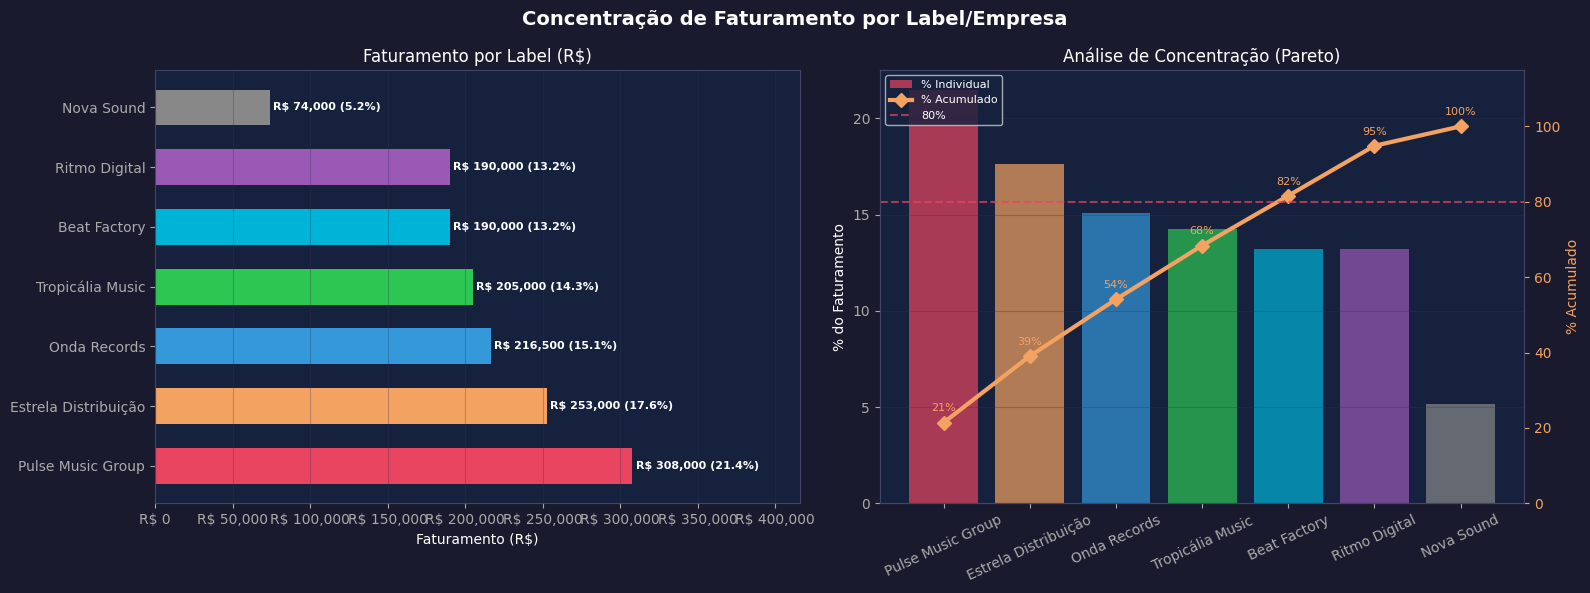

In [15]:
# ─── Gráfico: Concentração Labels ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(COLORS['bg_dark'])
fig.suptitle('Concentração de Faturamento por Label/Empresa', fontsize=14, fontweight='bold', color='white')

# Barras horizontais
ax1 = axes[0]
ax1.set_facecolor(COLORS['bg_card'])
palette = [COLORS['accent'], COLORS['warning'], COLORS['info'], COLORS['success'],
           COLORS['primary'], COLORS['purple'], COLORS['muted']]
bars = ax1.barh(fat_label.index, fat_label['Faturamento'], color=palette, height=0.6)
for bar, val, pct in zip(bars, fat_label['Faturamento'], fat_label['% Faturamento']):
    ax1.text(bar.get_width()+2000, bar.get_y()+bar.get_height()/2,
             f'R$ {val:,.0f} ({pct:.1f}%)', va='center', fontsize=8, fontweight='bold')
ax1.set_title('Faturamento por Label (R$)', color='white')
ax1.set_xlabel('Faturamento (R$)', color='white')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R$ {x:,.0f}'))
ax1.grid(axis='x', alpha=0.3)
ax1.set_xlim(0, fat_label['Faturamento'].max() * 1.35)

# Curva de Lorenz / Pareto
ax2 = axes[1]
ax2.set_facecolor(COLORS['bg_card'])
x_vals = list(range(1, len(fat_label)+1))
ax2.bar(fat_label.index, fat_label['% Faturamento'], color=palette, alpha=0.7, label='% Individual')
ax2_2 = ax2.twinx()
ax2_2.plot(fat_label.index, fat_label['Acumulado %'], color=COLORS['warning'],
           lw=3, marker='D', ms=7, label='% Acumulado')
ax2_2.axhline(80, color=COLORS['accent'], lw=1.5, ls='--', alpha=0.7, label='80%')
ax2_2.set_ylim(0, 115)
ax2_2.set_ylabel('% Acumulado', color=COLORS['warning'])
ax2_2.tick_params(axis='y', colors=COLORS['warning'])
for i, (x, y) in enumerate(zip(fat_label.index, fat_label['Acumulado %'])):
    ax2_2.annotate(f'{y:.0f}%', (x, y), textcoords='offset points',
                   xytext=(0, 8), ha='center', fontsize=8, color=COLORS['warning'])
ax2.set_title('Análise de Concentração (Pareto)', color='white')
ax2.set_ylabel('% do Faturamento', color='white')
ax2.tick_params(axis='x', rotation=25)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_2.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_concentracao_labels.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg_dark'])
plt.show()

---
## ⚙️ Parte 2 — Visão Operacional

### (f) Análise por Responsável

In [16]:
# ─── Responsáveis ────────────────────────────────────────────────────────────
fat_resp = df.groupby('Responsável').agg(
    Campanhas=('Código', 'count'),
    Faturamento=('Valor Campanha (R$)', 'sum'),
    Ticket=('Valor Campanha (R$)', 'mean'),
    Views=('Views Entregues', 'sum')
).sort_values('Campanhas', ascending=False)

fat_resp['% Campanhas']   = fat_resp['Campanhas']   / fat_resp['Campanhas'].sum()   * 100
fat_resp['% Faturamento'] = fat_resp['Faturamento']  / fat_resp['Faturamento'].sum() * 100

print("ANÁLISE POR RESPONSÁVEL")
print("-" * 65)
for resp, row in fat_resp.iterrows():
    carga = "🔴 ALTO" if row['Campanhas'] >= 22 else "🟡 MÉDIO" if row['Campanhas'] >= 16 else "🟢 BAIXO"
    print(f"  {resp:<14} | {row['Campanhas']:>2} camp. ({row['% Campanhas']:.0f}%) | "
          f"R$ {row['Faturamento']:>8,.0f} ({row['% Faturamento']:.0f}%) | "
          f"Ticket: R$ {row['Ticket']:>7,.0f} | Carga: {carga}")
print()
print("📌 Observações:")
print("  → Analista 1 lidera em campanhas (22) e faturamento (R$ 503.5k)")
print("  → Coordenador tem o menor ticket médio (R$ 16.9k) — possível perfil de suporte")
print("  → Analista 2 tem apenas 16 campanhas — potencial de ampliação de carteira")

ANÁLISE POR RESPONSÁVEL
-----------------------------------------------------------------
  Analista 1     | 22.0 camp. (31%) | R$  503,500 (35%) | Ticket: R$  22,886 | Carga: 🔴 ALTO
  Analista 3     | 21.0 camp. (30%) | R$  404,000 (28%) | Ticket: R$  19,238 | Carga: 🟡 MÉDIO
  Analista 2     | 16.0 camp. (23%) | R$  343,000 (24%) | Ticket: R$  21,438 | Carga: 🟡 MÉDIO
  Coordenador    | 11.0 camp. (16%) | R$  186,000 (13%) | Ticket: R$  16,909 | Carga: 🟢 BAIXO

📌 Observações:
  → Analista 1 lidera em campanhas (22) e faturamento (R$ 503.5k)
  → Coordenador tem o menor ticket médio (R$ 16.9k) — possível perfil de suporte
  → Analista 2 tem apenas 16 campanhas — potencial de ampliação de carteira


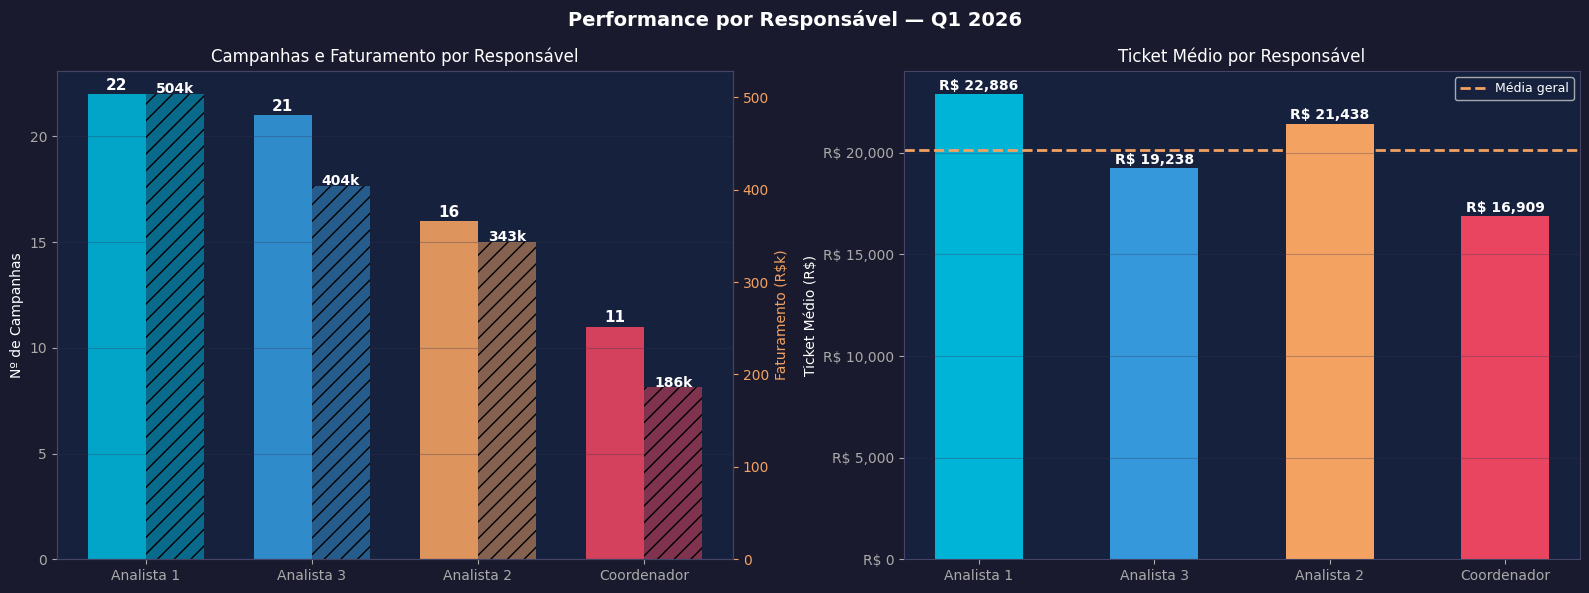

In [17]:
# ─── Gráfico: Responsáveis ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(COLORS['bg_dark'])
fig.suptitle('Performance por Responsável — Q1 2026', fontsize=14, fontweight='bold', color='white')

resp_colors_map = {
    'Analista 1': COLORS['primary'], 'Analista 2': COLORS['warning'],
    'Analista 3': COLORS['info'],    'Coordenador': COLORS['accent']
}
colors_r = [resp_colors_map.get(r, COLORS['muted']) for r in fat_resp.index]

ax1 = axes[0]
ax1.set_facecolor(COLORS['bg_card'])
x = np.arange(len(fat_resp))
w = 0.35
b1 = ax1.bar(x - w/2, fat_resp['Campanhas'], w, color=colors_r, alpha=0.9, label='Campanhas')
ax1b = ax1.twinx()
b2 = ax1b.bar(x + w/2, fat_resp['Faturamento']/1000, w, color=colors_r, alpha=0.5, label='Faturamento (R$k)', hatch='//')
for bar, val in zip(b1, fat_resp['Campanhas']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, str(val),
             ha='center', fontsize=11, fontweight='bold')
for bar, val in zip(b2, fat_resp['Faturamento']/1000):
    ax1b.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.0f}k',
              ha='center', fontsize=10, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(fat_resp.index)
ax1.set_ylabel('Nº de Campanhas', color='white')
ax1b.set_ylabel('Faturamento (R$k)', color=COLORS['warning'])
ax1b.tick_params(axis='y', colors=COLORS['warning'])
ax1.set_title('Campanhas e Faturamento por Responsável', color='white')
ax1.grid(axis='y', alpha=0.3)

# Ticket médio
ax2 = axes[1]
ax2.set_facecolor(COLORS['bg_card'])
bars2 = ax2.bar(fat_resp.index, fat_resp['Ticket'], color=colors_r, width=0.5)
ax2.axhline(fat_resp['Ticket'].mean(), color=COLORS['warning'], lw=2, ls='--', label='Média geral')
for bar, val in zip(bars2, fat_resp['Ticket']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'R$ {val:,.0f}', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Ticket Médio por Responsável', color='white')
ax2.set_ylabel('Ticket Médio (R$)', color='white')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R$ {x:,.0f}'))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_responsaveis.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg_dark'])
plt.show()

### (g) Análise por Gênero Musical

In [18]:
# ─── Gêneros ─────────────────────────────────────────────────────────────────
fat_genero = df.groupby('Gênero').agg(
    Faturamento=('Valor Campanha (R$)', 'sum'),
    Campanhas=('Código', 'count'),
    Ticket=('Valor Campanha (R$)', 'mean'),
    CPM=('CPM', 'mean')
).sort_values('Faturamento', ascending=False)

fat_genero['% Faturamento'] = fat_genero['Faturamento'] / fat_genero['Faturamento'].sum() * 100

print("ANÁLISE POR GÊNERO MUSICAL")
print("-" * 75)
print(fat_genero[['Campanhas','Faturamento','% Faturamento','Ticket']]
      .assign(Faturamento=fat_genero['Faturamento'].map(lambda x: f'R$ {x:,.0f}'))
      .assign(**{'% Faturamento': fat_genero['% Faturamento'].map(lambda x: f'{x:.1f}%')})
      .assign(Ticket=fat_genero['Ticket'].map(lambda x: f'R$ {x:,.0f}'))
      .to_string())

ANÁLISE POR GÊNERO MUSICAL
---------------------------------------------------------------------------
            Campanhas Faturamento % Faturamento     Ticket
Gênero                                                    
Eletrônica          8  R$ 291,000         20.3%  R$ 36,375
Trap               11  R$ 281,000         19.6%  R$ 25,545
R&B                 8  R$ 150,000         10.4%  R$ 18,750
Funk                7  R$ 145,000         10.1%  R$ 20,714
Axé                 7  R$ 139,000          9.7%  R$ 19,857
Pop                 7  R$ 111,000          7.7%  R$ 15,857
Forró               6   R$ 93,000          6.5%  R$ 15,500
Rap                 4   R$ 77,000          5.4%  R$ 19,250
Pagode              6   R$ 67,500          4.7%  R$ 11,250
Sertanejo           5   R$ 52,000          3.6%  R$ 10,400
Piseiro             1   R$ 30,000          2.1%  R$ 30,000


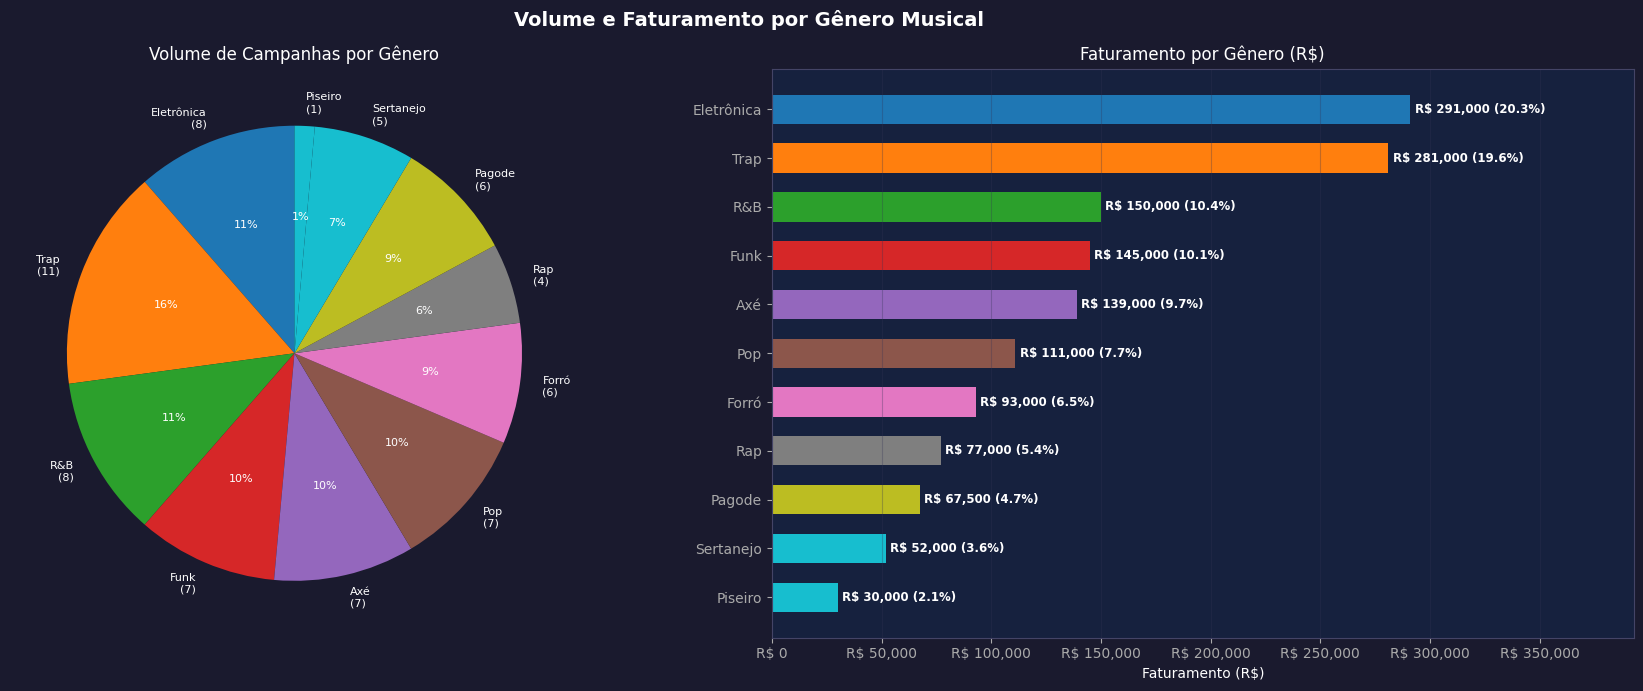

In [19]:
# ─── Gráfico: Gêneros ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(COLORS['bg_dark'])
fig.suptitle('Volume e Faturamento por Gênero Musical', fontsize=14, fontweight='bold', color='white')

palette_gen = plt.cm.tab10(np.linspace(0, 1, len(fat_genero)))

ax1 = axes[0]
ax1.set_facecolor(COLORS['bg_card'])
wedges, texts, autotexts = ax1.pie(
    fat_genero['Campanhas'],
    labels=[f"{g}\n({c})" for g, c in zip(fat_genero.index, fat_genero['Campanhas'])],
    autopct='%1.0f%%', colors=palette_gen, startangle=90,
    textprops={'fontsize': 8, 'color': 'white'})
for at in autotexts:
    at.set_fontsize(8); at.set_color('white')
ax1.set_title('Volume de Campanhas por Gênero', color='white')

ax2 = axes[1]
ax2.set_facecolor(COLORS['bg_card'])
bars = ax2.barh(fat_genero.index[::-1], fat_genero['Faturamento'][::-1], color=palette_gen[::-1], height=0.6)
for bar, val, pct in zip(bars, fat_genero['Faturamento'][::-1], fat_genero['% Faturamento'][::-1]):
    ax2.text(bar.get_width()+2000, bar.get_y()+bar.get_height()/2,
             f'R$ {val:,.0f} ({pct:.1f}%)', va='center', fontsize=8.5, fontweight='bold')
ax2.set_title('Faturamento por Gênero (R$)', color='white')
ax2.set_xlabel('Faturamento (R$)', color='white')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R$ {x:,.0f}'))
ax2.grid(axis='x', alpha=0.3)
ax2.set_xlim(0, fat_genero['Faturamento'].max() * 1.35)

plt.tight_layout()
plt.savefig('grafico_generos.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg_dark'])
plt.show()

### (h) CPM médio por gênero e label

In [20]:
# ─── CPM ─────────────────────────────────────────────────────────────────────
df_fin = df[df['Campanha Finalizada']=='Sim'].dropna(subset=['CPM'])

cpm_geral = df_fin['CPM'].mean()
print(f"CPM Médio Geral: R$ {cpm_geral:.4f} por 1.000 views")
print()

cpm_genero = df_fin.groupby('Gênero')['CPM'].agg(['mean','count','std']).sort_values('mean')
cpm_genero.columns = ['CPM Médio','Campanhas','Desvio Padrão']
print("CPM POR GÊNERO (menor = mais eficiente = mais views por real)")
print("-" * 60)
for gen, row in cpm_genero.iterrows():
    efic = "🟢 Muito eficiente" if row['CPM Médio'] < 0.5 else "🟡 Moderado" if row['CPM Médio'] < 1.5 else "🔴 Alto CPM"
    print(f"  {gen:<12} CPM R$ {row['CPM Médio']:.4f} | {row['Campanhas']:.0f} camp. | {efic}")
print()

cpm_label = df_fin.groupby('Empresa/Label')['CPM'].mean().sort_values()
print("CPM POR LABEL:")
print(cpm_label.map(lambda x: f'R$ {x:.4f}').to_string())

CPM Médio Geral: R$ 1.6478 por 1.000 views

CPM POR GÊNERO (menor = mais eficiente = mais views por real)
------------------------------------------------------------
  R&B          CPM R$ 0.3523 | 6 camp. | 🟢 Muito eficiente
  Sertanejo    CPM R$ 0.5039 | 4 camp. | 🟡 Moderado
  Axé          CPM R$ 0.5429 | 6 camp. | 🟡 Moderado
  Forró        CPM R$ 0.5699 | 4 camp. | 🟡 Moderado
  Funk         CPM R$ 0.6276 | 5 camp. | 🟡 Moderado
  Rap          CPM R$ 0.6539 | 2 camp. | 🟡 Moderado
  Pagode       CPM R$ 0.6674 | 2 camp. | 🟡 Moderado
  Pop          CPM R$ 0.6930 | 6 camp. | 🟡 Moderado
  Trap         CPM R$ 3.0659 | 9 camp. | 🔴 Alto CPM
  Eletrônica   CPM R$ 5.2629 | 7 camp. | 🔴 Alto CPM

CPM POR LABEL:
Empresa/Label
Tropicália Music        R$ 0.4547
Nova Sound              R$ 0.5247
Pulse Music Group       R$ 0.5795
Onda Records            R$ 0.5976
Estrela Distribuição    R$ 0.6756
Ritmo Digital           R$ 4.1824
Beat Factory            R$ 4.3385


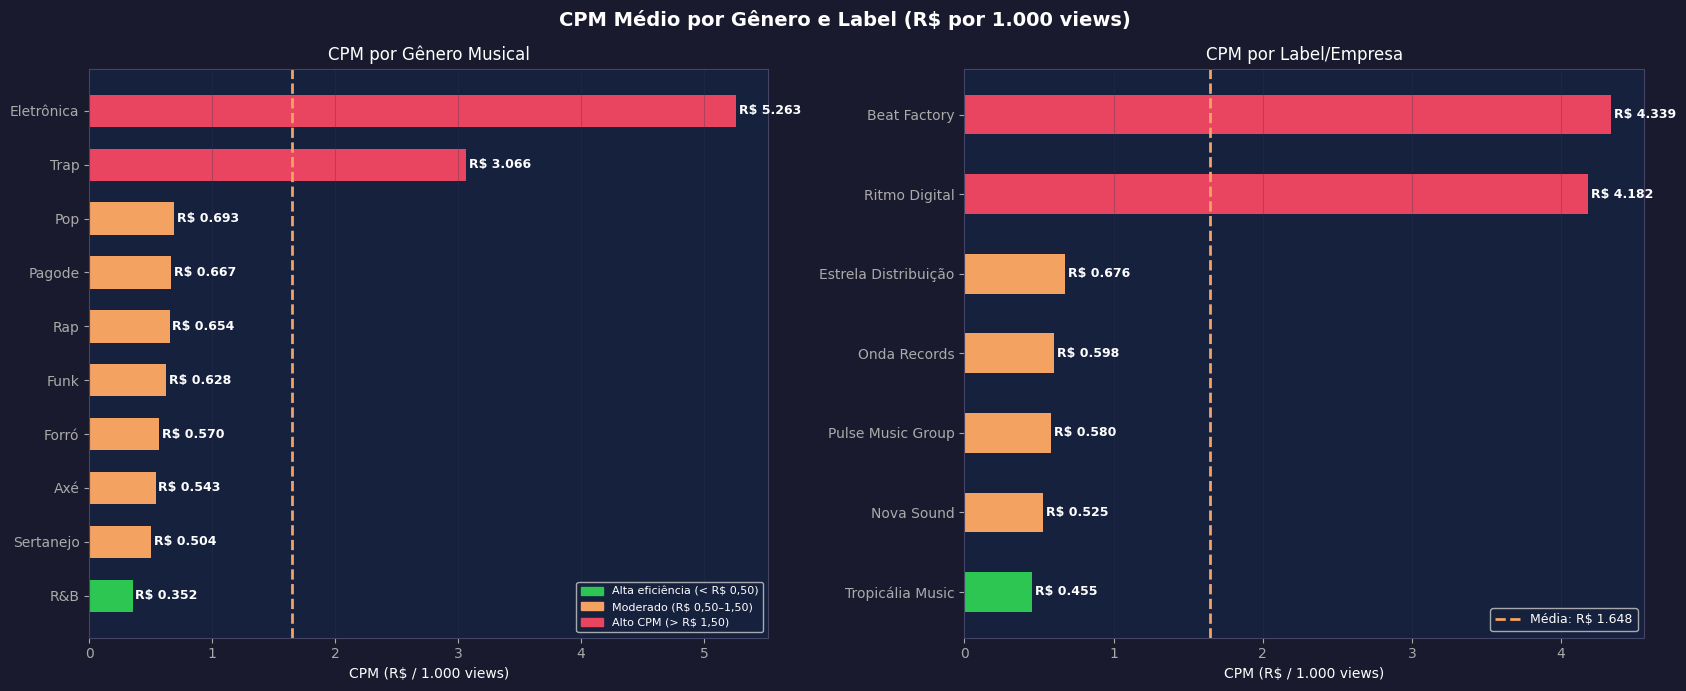

In [21]:
# ─── Gráfico: CPM ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.patch.set_facecolor(COLORS['bg_dark'])
fig.suptitle('CPM Médio por Gênero e Label (R$ por 1.000 views)', fontsize=14, fontweight='bold', color='white')

ax1 = axes[0]
ax1.set_facecolor(COLORS['bg_card'])
cpm_g = df_fin.groupby('Gênero')['CPM'].mean().sort_values()
colors_cpm = [COLORS['success'] if v < 0.5 else COLORS['warning'] if v < 1.5 else COLORS['accent'] for v in cpm_g.values]
bars1 = ax1.barh(cpm_g.index, cpm_g.values, color=colors_cpm, height=0.6)
ax1.axvline(cpm_geral, color=COLORS['warning'], lw=2, ls='--', label=f'Média: R$ {cpm_geral:.3f}')
for bar, val in zip(bars1, cpm_g.values):
    ax1.text(val+0.02, bar.get_y()+bar.get_height()/2,
             f'R$ {val:.3f}', va='center', fontsize=9, fontweight='bold')
ax1.set_title('CPM por Gênero Musical', color='white')
ax1.set_xlabel('CPM (R$ / 1.000 views)', color='white')
ax1.legend(fontsize=9)
ax1.grid(axis='x', alpha=0.3)

legend_patches = [
    mpatches.Patch(color=COLORS['success'], label='Alta eficiência (< R$ 0,50)'),
    mpatches.Patch(color=COLORS['warning'], label='Moderado (R$ 0,50–1,50)'),
    mpatches.Patch(color=COLORS['accent'],  label='Alto CPM (> R$ 1,50)'),
]
ax1.legend(handles=legend_patches, fontsize=8, loc='lower right')

ax2 = axes[1]
ax2.set_facecolor(COLORS['bg_card'])
cpm_l = df_fin.groupby('Empresa/Label')['CPM'].mean().sort_values()
colors_cpm_l = [COLORS['success'] if v < 0.5 else COLORS['warning'] if v < 1.5 else COLORS['accent'] for v in cpm_l.values]
bars2 = ax2.barh(cpm_l.index, cpm_l.values, color=colors_cpm_l, height=0.5)
ax2.axvline(cpm_geral, color=COLORS['warning'], lw=2, ls='--', label=f'Média: R$ {cpm_geral:.3f}')
for bar, val in zip(bars2, cpm_l.values):
    ax2.text(val+0.02, bar.get_y()+bar.get_height()/2,
             f'R$ {val:.3f}', va='center', fontsize=9, fontweight='bold')
ax2.set_title('CPM por Label/Empresa', color='white')
ax2.set_xlabel('CPM (R$ / 1.000 views)', color='white')
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_cpm.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg_dark'])
plt.show()

---
## 💡 Parte 3 — Recomendações Estratégicas

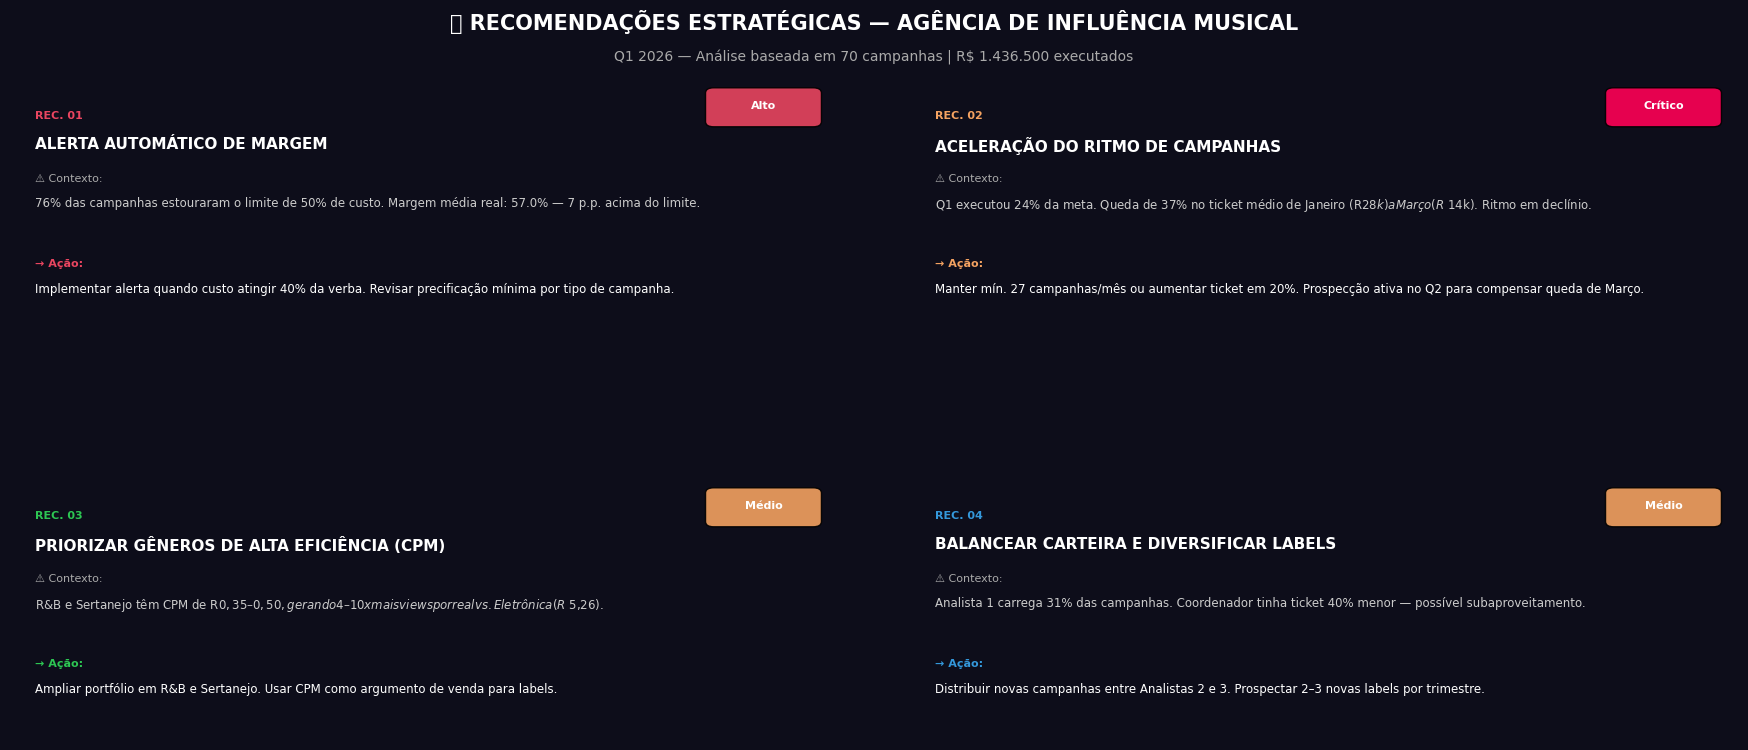

✅ Dashboard de recomendações gerado.


In [23]:
# ─── Dashboard Executivo de Recomendações ───────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0D0D1A')

# Título
fig.text(0.5, 0.95, '🎵 RECOMENDAÇÕES ESTRATÉGICAS — AGÊNCIA DE INFLUÊNCIA MUSICAL',
         ha='center', va='top', fontsize=15, fontweight='bold', color='white')
fig.text(0.5, 0.91, 'Q1 2026 — Análise baseada em 70 campanhas | R$ 1.436.500 executados',
         ha='center', va='top', fontsize=10, color='#AAAAAA')

recs = [
    {
        'icon': '🔴', 'numero': '01',
        'titulo': 'ALERTA AUTOMÁTICO DE MARGEM',
        'problema': f'76% das campanhas estouraram o limite de 50% de custo. Margem média real: {57.0:.1f}% — 7 p.p. acima do limite.',
        'acao': 'Implementar alerta quando custo atingir 40% da verba. Revisar precificação mínima por tipo de campanha.',
        'impacto': 'Alto',
        'cor': '#E94560',
        'cor_fundo': '#2A0A10',
    },
    {
        'icon': '🟡', 'numero': '02',
        'titulo': 'ACELERAÇÃO DO RITMO DE CAMPANHAS',
        'problema': 'Q1 executou 24% da meta. Queda de 37% no ticket médio de Janeiro (R$ 28k) a Março (R$ 14k). Ritmo em declínio.',
        'acao': 'Manter mín. 27 campanhas/mês ou aumentar ticket em 20%. Prospecção ativa no Q2 para compensar queda de Março.',
        'impacto': 'Crítico',
        'cor': '#F4A261',
        'cor_fundo': '#2A1A05',
    },
    {
        'icon': '🟢', 'numero': '03',
        'titulo': 'PRIORIZAR GÊNEROS DE ALTA EFICIÊNCIA (CPM)',
        'problema': 'R&B e Sertanejo têm CPM de R$ 0,35–0,50, gerando 4–10x mais views por real vs. Eletrônica (R$ 5,26).',
        'acao': 'Ampliar portfólio em R&B e Sertanejo. Usar CPM como argumento de venda para labels.',
        'impacto': 'Médio',
        'cor': '#2DC653',
        'cor_fundo': '#0A2A10',
    },
    {
        'icon': '🔵', 'numero': '04',
        'titulo': 'BALANCEAR CARTEIRA E DIVERSIFICAR LABELS',
        'problema': 'Analista 1 carrega 31% das campanhas. Coordenador tinha ticket 40% menor — possível subaproveitamento.',
        'acao': 'Distribuir novas campanhas entre Analistas 2 e 3. Prospectar 2–3 novas labels por trimestre.',
        'impacto': 'Médio',
        'cor': '#3498DB',
        'cor_fundo': '#0A1A2A',
    },
]

for i, rec in enumerate(recs):
    x_pos = 0.02 + (i % 2) * 0.5
    y_pos = 0.62 if i < 2 else 0.22

    ax = fig.add_axes([x_pos, y_pos, 0.46, 0.26])
    ax.set_facecolor(rec['cor_fundo'])
    ax.set_xlim(0, 10); ax.set_ylim(0, 5)
    ax.axis('off')

    # Borda colorida
    for spine in ['top','bottom','left','right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(rec['cor'])
        ax.spines[spine].set_linewidth(2)

    # Número e título
    ax.text(0.3, 4.4, f"REC. {rec['numero']}", fontsize=8, color=rec['cor'],
            fontweight='bold', va='top')
    ax.text(0.3, 3.9, rec['titulo'], fontsize=11, color='white', fontweight='bold', va='top')

    # Problema
    ax.text(0.3, 3.2, '⚠ Contexto:', fontsize=8, color='#AAAAAA', va='top')
    ax.text(0.3, 2.75, rec['problema'], fontsize=8.5, color='#CCCCCC', va='top', linespacing=1.5)

    # Ação
    ax.text(0.3, 1.55, '→ Ação:', fontsize=8, color=rec['cor'], va='top', fontweight='bold')
    ax.text(0.3, 1.1, rec['acao'], fontsize=8.5, color='white', va='top', linespacing=1.5)

    # Badge impacto
    badge_color = {'Alto': '#E94560', 'Crítico': '#FF0055', 'Médio': '#F4A261'}.get(rec['impacto'], '#888')
    ax.add_patch(FancyBboxPatch((8.5, 4.2), 1.2, 0.55, boxstyle='round,pad=0.1',
                                facecolor=badge_color, alpha=0.9))
    ax.text(9.1, 4.5, rec['impacto'], ha='center', va='center', fontsize=8,
            color='white', fontweight='bold')

plt.savefig('grafico_recomendacoes.png', dpi=150, bbox_inches='tight', facecolor='#0D0D1A')
plt.show()
print("✅ Dashboard de recomendações gerado.")

---
## 📋 Resumo Final — Todos os KPIs

In [24]:
# ─── KPI Summary ─────────────────────────────────────────────────────────────
print("=" * 65)
print("RESUMO EXECUTIVO — Q1 2026")
print("=" * 65)
print()
print("📊 FINANCEIRO")
print(f"   Faturamento Q1:           R$ {1_436_500:>10,.0f}")
print(f"   % Meta Anual Atingida:    {1_436_500/6_000_000*100:>9.1f}%")
print(f"   Ticket Médio:             R$ {df['Valor Campanha (R$)'].mean():>10,.0f}")
print(f"   Melhor Mês:               {'Janeiro':>12} (R$ 567.000)")
print(f"   Pior Mês:                 {'Março':>12} (R$ 351.500)")
print()
print("⚙️  OPERACIONAL")
print(f"   Total Campanhas:          {70:>12}")
print(f"   Gênero Top Faturamento:   {'Eletrônica':>12} (R$ 291.000)")
print(f"   Gênero Top Volume:        {'Trap':>12} (11 campanhas)")
print(f"   Melhor CPM (eficiência):  {'R&B':>12} (R$ 0,352/1k views)")
print(f"   Analista + Campanhas:     {'Analista 1':>12} (22 campanhas)")
print(f"   Analista + Faturamento:   {'Analista 1':>12} (R$ 503.500)")
print()
print("💰 MARGEM")
print(f"   Com custo informado:      {70:>12} campanhas")
print(f"   Dentro da margem (≤50%): {17:>12} ({17/70*100:.0f}%)")
print(f"   Estouraram (>50%):        {53:>12} ({53/70*100:.0f}%)")
print(f"   Margem média real:        {57.02:>11.1f}%")
print()
print("🎯 PROJEÇÃO")
print(f"   Ritmo mensal atual:       R$ {478_833:>10,.0f}")
print(f"   Projeção anual:           R$ {5_745_996:>10,.0f}")
print(f"   GAP para meta:            R$ {254_004:>10,.0f}")
print(f"   Necessário/mês (Q2-Q4):   R$ {507_056:>10,.0f}")
print("=" * 65)

RESUMO EXECUTIVO — Q1 2026

📊 FINANCEIRO
   Faturamento Q1:           R$  1,436,500
   % Meta Anual Atingida:         23.9%
   Ticket Médio:             R$     40,465
   Melhor Mês:                    Janeiro (R$ 567.000)
   Pior Mês:                        Março (R$ 351.500)

⚙️  OPERACIONAL
   Total Campanhas:                    70
   Gênero Top Faturamento:     Eletrônica (R$ 291.000)
   Gênero Top Volume:                Trap (11 campanhas)
   Melhor CPM (eficiência):           R&B (R$ 0,352/1k views)
   Analista + Campanhas:       Analista 1 (22 campanhas)
   Analista + Faturamento:     Analista 1 (R$ 503.500)

💰 MARGEM
   Com custo informado:                70 campanhas
   Dentro da margem (≤50%):           17 (24%)
   Estouraram (>50%):                  53 (76%)
   Margem média real:               57.0%

🎯 PROJEÇÃO
   Ritmo mensal atual:       R$    478,833
   Projeção anual:           R$  5,745,996
   GAP para meta:            R$    254,004
   Necessário/mês (Q2-Q4):   R$    507